# INFEWS Farm Model

## Objective and Prerequisites

This model is based of the example of a stochastic optimization problem from [Gurobi](https://www.gurobi.com/resource/solving-simple-stochastic-optimization-problems-with-gurobi/). That problem asked you to consider a situation where you have to buy today the stock of products to sell tomorrow but you don't know the exact demand you will see. Then you will have to decide what to do with whatever is left which includes selling it for scrap. This is called the Newspaper Vendor Problem. 


---
## Problem Description

For our problem a farm must decide how to prepare for different climate futures. Each climate future has different precipation patterns that will affect how much irrigation water is needed for different plants. Our farm must decide if and how much alternative water and electricity to invest in. Using a combination of precipation, alternative water, and irrigation water the decision makers maximizes profit where revenue is based on the price of the crop and the yield available and the costs are the costs of investing in alternative water and buying irrigation water. There are known costs associated with buying irrigation water, investing in alternative water, but the unknown is knowing how much water will be available as rain.

Our model has three indicies related to climate, season, and option. 

The climate index has to do with what the possible climate futures. In this model there are 3 climate futures.


| Climate | Description |
| --- | --- |
| C1 |  DFW Historical Precipitation |
| C2 |  Lubbock Historical Precipitation |
| C3 |  San Angelo Historical Precipitation |

The season index has to do with the number of growing seasons. In this model there are 5 growing seasons.

| Season | Description |
| --- | --- |
| S1 | Growing Season 1 that correlates with the first year |
| S2 | Growing Season 2 that correlates with the second year |
| S3 | Growing Season 3 that correlates with the third year |
| S4 | Growing Season 4 that correlates with the fourth year |
| S5 | Growing Season 5 that correlates with the fifth year |

The option index correlates to the possible precipatation values in each climate scenario. There are 5 options in each climate scenario

| Season | Description |
| --- | --- |
| O1 | Option 1 that correlates with a possible realization for a given climate scenario |
| O2 | Option 2 that correlates with a possible realization for a given climate scenario |
| O3 | Option 3 that correlates with a possible realization for a given climate scenario |
| O4 | Option 4 that correlates with a possible realization for a given climate scenario |
| O5 | Option 5 that correlates with a possible realization for a given climate scenario |



---
## Model Formulation

### Sets and Indices

$k \in \text{Climate}=\{\text{C1}, \text{C2}, \text{C3}\}$

$i \in \text{Season}=\{\text{S1}, \text{S2}, \text{S3}, \text{S4}, \text{S5}\}$

$j \in \text{Option}=\{\text{O1}, \text{O2}, \text{O3}, \text{O4}, \text{O5}\}$

$\text{Sets} = \text{Climate} \cup \text{Season} \cup \text{Option}$

### Parameters

$\text{alt_water}_{k} \in \mathbb{R}^+$: The amount of alternative water for climate scenario $k$

$\text{ha} \in \mathbb{R}^+$: Hectacres

$\text{price} \in \mathbb{R}^+$: Price of crop in tons

$\text{cost alt water} \in \mathbb{R}^+$: Cost of alternative water

$\text{salt concentration water} \in \mathbb{R}^+$: The salt concentration of water

$\text{salt concentration} \in \mathbb{R}^+$: The salt concentration of soil

$\text{alt water} \in \mathbb{R}^+$: The salt concentration of water





### Decision Variables

$\text{water}_{k,i,j} \in \mathbb{N}^+$: How much water to use for climate $k$, during season $i$, and option $j$. 

$\text{irrigation_water}_{k,i,j} \in \mathbb{N}^+$: How much irrigation water to buy for climate $k$, during season $i$, and option $j$. 

$\text{climate_choice} \in \mathbb{N}^+$:Which climate option do you choose

$\text{crop_yield}_{k,i,j} \in \mathbb{N}^+$: The yield based on the amount of water used in climate $k$, during season $i$, and option $j$. 


### Objective Function

- **Cost**: Minimize total shipping costs.

\begin{equation}
\text{Maximize} \quad Z = \sum_{(k,i,j) \in \text{Sets} \times \text{Sets}}
{\text{crop_yield}_{k,i,j} \times \text{ha} \times \text{price} - 
\text{alt_water}_{k} \times \text{cost_alt_water} \times \text{climate_choice}_{k} -
\text{irrigation_water}_{k,i,j} \times \text{cost_irrigation_water} }
\end{equation}

### Constraints

- **Water Used**: Water used must be less than or equal to the sum of the rain, irrigation, and alternative water.

\begin{equation}
\text{rain}_{k,i,j} + \text{climate_choice}_{k} \times \text{alt_water}_{k} + \text{irrigation_water}_{k,i,j} \geq \text{water}_{k,i,j} 
\quad \forall k \in \text{Climate} \quad \forall i \in \text{Season} \quad \forall j \in \text{Option}
\end{equation}

- **Crop Yield**: Crop yield is based on a production function based on water depth .

\begin{equation}
\sum_{s \in \text{Sets}}{\text{crop_yield}_{k,i,j} \leq -3.35 + 0.2064 \times \text{water}_{k,i,j} - 0.0014 \times \text{water}_{k,i,j}^2 + 2.326 \times \text{salt_conc_water}^2 - 2.031 \times \text{salt_conc} + 2.326 \times \text{salt_conc}^2 } - 0.071 \times \text{water}_{k,i,j} \times \text{salt_conc_water} + 0.033 \times \text{water}_{k,i,j} \times \text{salt_conc}  
\quad \forall k \in \text{Climate} \quad \forall i \in \text{Season} \quad \forall j \in \text{Option}
\end{equation}


- **Climate Choice**: Must choose one climate choice

\begin{equation}
\sum_{k \in Climate} {\text{Climate}_{k} } = 1
\end{equation}

---
## Python Implementation

We import the Gurobi Python Module and other Python libraries.

Import Libraries, Helpful Links, and Making Sure all Results show after each chunk.

In [1]:
from gurobipy import * 
import gurobipy as gp
import random
random.seed(a=100)
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import gridspec
from matplotlib.ticker import PercentFormatter
import numpy as np


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Problem Source: https://www.gurobi.com/resource/solving-simple-stochastic-optimization-problems-with-gurobi/
# Matplotlib documentation: https://matplotlib.org/tutorials/introductory/pyplot.html
# Pandas documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html

Some helpful conversions.
And some parameterization and upper and lower bounds.

In [2]:
# Conversions

cm2_ha = 100000000 # 100,000,000 cm2 = 1 ha

cm3_gal = 3785.41 # 3785.41 cm2 = 1 Gal

gal_acre_ft = 325851 # 1 acre ft = 325851 gallons

acre_ha = 2.47105 # 1 hectare = 2.47105 acres

cm_ft = 30.48 # 1 ft = 30.48 cm

cm_in = 2.54

lb_tonne = 2204.62

# Parameters

ha = 10 # hectares

price = 200 # $/ metric ton #https://www.indexmundi.com/commodities/?commodity=wheat

#note $ /acre ranges from $7-85 / acre assuming only a few cm of depth similiar price to irrigation water 

cost_alt_water = 60 # $ / cm



# Irrigation Water Cost https://news.berkeley.edu/berkeley_blog/the-cost-of-irrigation-water-and-urban-farming/
#  Given in $ / cm from: $ 40 / acre-ft / gal_acre_ft / cm3_gal * cm2_ha * ha 

cost_irrigation_water = 40 / gal_acre_ft / cm3_gal * cm2_ha * ha  # $ / cm 


salt_conc = 2 # deciSiemens / meter = dS/m

salt_conc_water = 1 # deciSiemens / meter = dS/m

precip = 20 * cm_in # 20 inches of rain


irrigation_water_limit = 0.75 # acre-ft / acre https://www.nass.usda.gov/Publications/Highlights/2019/2017Census_Irrigation_and_WaterManagement.pdf

max_irrigation_water = irrigation_water_limit * cm_ft




Seeting the precipatation values.

This is where I can create climate regimes. 

Have certain climate regimes have certain values of precipatation

In [3]:
# Precipation Data from weather.gov NOWData NOAA Online Weather Data from 1990-2020 for DFW, Lubbock, and San Angelo
# Climate Zones https://www.energy.gov/sites/prod/files/2015/10/f27/ba_climate_region_guide_7.3.pdf
# NOAA Climate Zones https://scijinks.gov/climate-zones/

precip_dfw = [45.27, 53.54, 42.19, 32.83, 44.1, 35.39, 33.14, 45, 34.24, 23.59, 36.25, 38.13, 44.42, 24.55, 47.57, 18.97, 29.75, 50.05, 27.1, 40.89, 31.7, 25.88, 31.26, 29.4, 21.32, 62.61, 35.48, 36.62, 55.97, 34.52, 43.7]
precip_lubbock = [15.83, 24.04, 22.39, 12.75, 13.12, 18.75, 14.12, 22.67, 13.05, 20.19, 21.27, 15.55, 19.27, 8.81, 33.25, 15.04, 15.56, 23.94, 28, 12.87, 26.46, 5.86, 11.43, 12.61, 22.56, 29.45, 13.47, 21.95, 15.27, 24.37, 11.55]
precip_sanangelo = [28.8, 24.29, 21.03, 15.63, 19.4, 21.15, 22.5, 23.38, 12.98, 13.52, 15.19, 18.52, 14.42, 19.76, 30.49, 20.38, 17.65, 32.04, 19, 25.53, 20.13, 9.21, 21.96, 19.8, 16.71, 26.78, 35.72, 18.48, 34.06, 17.73, 20.06]

precip_c1 = np.array(precip_dfw)
precip_c2 = np.array(precip_lubbock)
precip_c3 = np.array(precip_sanangelo)


precip = np.concatenate((precip_dfw,precip_lubbock, precip_sanangelo))

precip = precip * cm_in / 4 # annual precipation values divided by 4 for a seasonal value
np.mean(precip)

len(precip)
samples = len(precip)

16.23128279569892

93

A quick chart showing the effect of water depth on yield and price.

Text(0.5, 1.0, 'Profit and Yield by Preciptation')

Text(0.5, 0, 'Water Depth (cm)')

Text(0, 0.5, 'Profit ($)')

(-100.0, 7200.0)

Text(0, 0.5, 'Yield (tonnes/ha)')

(-100.0, 8500.0)

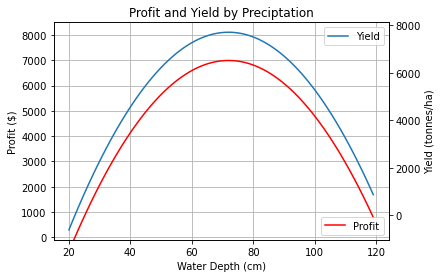

In [4]:
alt_water = 0
irrigation_water = 0
#irrigation_water = np.array(range(100))
water = np.array(range(100))+20
#water = alt_water + irrigation_water + precip

# From Dinar et. al 1991 "Production functions relating crop yield, water quality and quantity, soil salinity and drainage volume"

y1 = (-3.350 + 0.2064*water - 0.0014*water*water + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water 
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc
               -0.071 * water * salt_conc_water + 0.033 * water * salt_conc 
               -2.754 * salt_conc_water * salt_conc)

p1 = (y1*ha*price +
              -alt_water * (ha*cm2_ha/cm3_gal) * cost_alt_water +
              -irrigation_water * (ha*cm2_ha/cm3_gal) * cost_irrigation_water )

fig, ax = plt.subplots()

ax.plot(water,p1, label = 'Profit', color = 'red') # profit is red line
ax.set_title('Profit and Yield by Preciptation')
ax.set_xlabel('Water Depth (cm)')
ax.set_ylabel('Profit ($)')
ax.set_ylim([-100,7200])
ax.grid(True)
ax.legend(loc = 'lower right')

ax2 = ax.twinx()
ax2.plot(water,y1*lb_tonne, label = 'Yield') # yield is blue line
ax2.set_ylabel('Yield (tonnes/ha)')
ax.set_ylim([-100,8500])
ax2.legend()
plt.show()


#plt.plot(irrigation_water,p1)








Another useful bound to speed up computational time. The max price is as good as it gets and since the above code doesn't have any cost max price is max rev.

This code defines the charts that are used in the other Stochastic programs.

In [5]:
# Conditional value at risk (for losses) is the expected value of the worst alpha% tail of the realizations 
# in the random variable (represented in this case as a list of values)
# alpha: a value in ]0,1[
# data: a list of values
def CVaR(data,alpha):
    data.sort()
    n = len(data)
    m = int(alpha*n)
    return sum(data[m:-1])/len(data[m:-1])

# Prints the double histogram of a random variable (represented in this case as a list of values)
# First the empirical density distribution, and then the empirical accumulated probability

n_bins = 150

def doubleHist(data, xlabel=None):
    plt.figure(figsize=(14.5,6),dpi=600)
    gs  = gridspec.GridSpec(1, 2, width_ratios=[5, 1], wspace=0.25)
    ax  = plt.subplot(gs[0])
    ax3 = plt.subplot(gs[1])
    ax.grid(True)
    ax.set_title(xlabel)
    ax.set_ylabel('Likelihood of occurrence',color='blue')
    ax2 = ax.twinx()
    ax2.set_ylabel('Cumulative probability',color='red')
    # plot the density and cumulative histogram
    n, bins, patches = ax.hist(data, n_bins, density=True, alpha=0.65, cumulative=False, label='Density', color='blue')
    n, bins, patches = ax2.hist(data, n_bins, density=True, histtype='step', cumulative=True, label='CDF', color='red')
    ax3.boxplot(data,whis=[5,95])
    # tidy up the figure
    plt.show()

#print basic info on optimal solution
def solutionStats(model, order, losses):
    global cost_alt_water
    losses.sort()
    samples = len(losses)
    print('Model Value', m.ObjVal, 'order Qty', alt_water.X, 'investment', alt_water.X*cost_alt_water, '#samples',samples)
    print('Losses stats:')
    print('CVaR(95%,90%,80%,70%)', CVaR(losses,0.95), CVaR(losses,0.90), CVaR(losses, 0.80), CVaR(losses,0.70))
    print('min', min(losses),'max', max(losses), 'average', sum(losses)/samples, 'VaR_75%', losses[int(0.75*samples)])

Defines the stochastic model. This model is simply a weighted average. Takes each possible precipatation and its corresponding yield and profit and averages them equally.

Variabels

alt_water; irrigation_water

water

crop_yield, profit

Objective functions are all profit and correspond to the different precipation scenarios. Need to change this to climaate scenarios.

Water is function of precipitation, alternative water and irrigation water.

Crop yield is function of saliniatity, soil, and water.


In [6]:
# To help get tight bounds on variables later on

maxrev  = max(p1)
minrev  = 0

#Water peaks profit and yield at 73

alt_water_c1 = max((73 - max_irrigation_water - np.mean(precip_c1)*cm_in/4),0)

alt_water_c2 = max((73 - max_irrigation_water - np.mean(precip_c2)*cm_in/4), 0 )

alt_water_c3 = max((73 - max_irrigation_water - np.mean(precip_c3)*cm_in/4) ,0)



In [7]:
m = Model()

#m.params.NonConvex = 2 # Says its non convex but it is (FIXED quadratic constraints can't be equality)

# Set to maximize
m.ModelSense = -1

# Add variables

#First Stage Decision Variables Strategic Investment Decisions, pick what climate you are in which automatically picks how much alternative water to invest in

#alt_water = m.addVar(name = 'alt_water') # cm of depth

c1 = m.addVar(ub = 1, vtype = GRB.INTEGER, name = 'pick_c1')
c2 = m.addVar(ub = 1, vtype = GRB.INTEGER, name = 'pick_c2')
c3 = m.addVar(ub = 1, vtype = GRB.INTEGER, name = 'pick_c3')


#Second Stage Decision Variables Operational Decisions, Pick how much water to use and how much irrigation water to buy

water = m.addVars(samples, lb = 0, name = 'water') # water used for crop, cm of depth
irrigation_water = m.addVars(samples, lb = 0, ub = max_irrigation_water, name = 'irrigation_water') # cm of depth

#Functions of the Above
crop_yield = m.addVars(samples,name = 'yield') # tonne/ha
profit = m.addVars(samples,obj = 1.0/len(precip), name = 'profit') # $


# Objective

m.addConstrs( (profit[i] == crop_yield[i] * ha * price +
              -alt_water_c1 * cost_alt_water * c1 +
              -alt_water_c2 * cost_alt_water * c2 +
              -alt_water_c3 * cost_alt_water * c3 +
              -irrigation_water[i] * cost_irrigation_water
             for i in range(samples) )
            ,name = 'profit')
# Set Constraints



m.addConstrs( (precip[i] + c1*alt_water_c1 + c2*alt_water_c2 + c3*alt_water_c3 + irrigation_water[i] >= water[i] 
              for i in range(samples) )
            ,name = 'water' )


m.addConstr( (c1 + c2 +c3 == 1), name = 'pick_climate')

for i in range(samples):
    m.addQConstr( (crop_yield[i] <= -3.350 + 0.2064*water[i] - 0.0014*water[i]*water[i] + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water +
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc +
               -0.071 * water[i] * salt_conc_water + 0.033 * water[i] * salt_conc +
               -2.754 * salt_conc_water * salt_conc
               )
               , name = 'crop_yield' )


m.update();




--------------------------------------------
--------------------------------------------

Academic license - for non-commercial use only - expires 2021-01-26
Using license file C:\Users\Jones\gurobi.lic


In [8]:
m.optimize()
obj = m.getObjective()
print(obj.getValue())
c1
c2
c3

Gurobi Optimizer version 9.1.1 build v9.1.1rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 187 rows, 375 columns and 1026 nonzeros
Model fingerprint: 0x5ac34035
Model has 93 quadratic constraints
Variable types: 372 continuous, 3 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  QMatrix range    [1e-03, 1e-03]
  QLMatrix range   [2e-01, 1e+00]
  Objective range  [1e-02, 1e-02]
  Bounds range     [1e+00, 2e+01]
  RHS range        [1e+00, 4e+01]
  QRHS range       [4e+00, 4e+00]
Presolve removed 0 rows and 93 columns
Presolve time: 0.02s
Presolved: 187 rows, 282 columns, 840 nonzeros
Presolved model has 93 quadratic constraint(s)
Variable types: 279 continuous, 3 integer (3 binary)
Presolve time: 0.05s
Presolved: 559 rows, 468 columns, 1491 nonzeros
Presolved model has 93 second-order cone constraints
Root barrier log...

Ordering time: 0.00s

Barrier statistics:
 Dense cols : 3
 AA' NZ     : 1.584

<gurobi.Var pick_c1 (value 0.9999999996058404)>

<gurobi.Var pick_c2 (value 1.8064001637855943e-10)>

<gurobi.Var pick_c3 (value 2.1351952917656773e-10)>

Showing all the results for each precipation scenario. Need to change this to climate scenario.

Text(0.5, 1.0, 'Profit and Yield by Preciptation')

Text(0.5, 0, 'Possible Outcome')

Text(0, 0.5, 'Profit ($) & Yield (lbs)')

(0.0, 8000.0)

Text(0, 0.5, 'Water (cm)')

(0.0, 200.0)

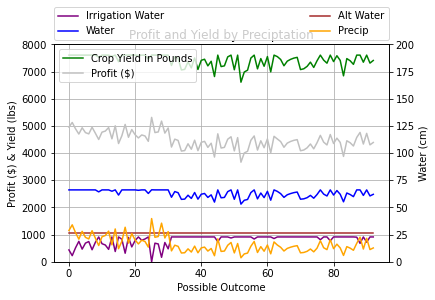

In [9]:



xs = np.array(range(samples)) # Setting the x axis for number of samples First 30 from Dallas Precip, NExt 30 from Lubbock, Last 30 from San Angelo
y0 = np.array([crop_yield[i].X for i in range(samples)])
y1 = [profit[i].X for i in range(samples)]
y2 = [irrigation_water[i].X for i in range(samples)]
y3 = [water[i].X for i in range(samples)]
y4 = y3 - precip
y4 = y4 -y2


fig, ax = plt.subplots()

ax.plot(xs,y0*lb_tonne, label = 'Crop Yield in Pounds', color = 'green') # profit is red line
ax.plot(xs,y1, label = 'Profit ($)', color = 'silver') # profit is red line
ax.set_title('Profit and Yield by Preciptation')
ax.set_xlabel('Possible Outcome')
ax.set_ylabel('Profit ($) & Yield (lbs)')
ax.set_ylim([0,8000])
ax.grid(True)
ax.legend(loc = 'upper left')

ax2 = ax.twinx()
ax2.plot(xs,y2, label = 'Irrigation Water', color = 'purple') # irrigation is blue line
ax2.plot(xs,y3, label = 'Water', color = 'blue') # water is green line
ax2.plot(xs,y4, label = 'Alt Water', color = 'brown') # water is green line
ax2.plot(xs,precip, label = 'Precip', color = 'orange') # water is green line
ax2.set_ylabel('Water (cm)')
ax2.set_ylim([0,200])
ax2.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower right', ncol=2, mode="expand", borderaxespad=0.)


plt.show()



In [10]:
climate = ['C1', 'C2', 'C3']
season = ['S1', 'S2', 'S3', 'S4', 'S5']
option = ['O1', 'O2', 'O3']

indicies = [(x,y,z) for x in climate for y in season for z in option]

rain = {}

for i in range(len(indicies)):
    rain[indicies[i]] = precip[i]/4

rain

samples = len(indicies)

c1_coef = 1
c2_coef = 1
c3_coef = 1

{('C1', 'S1', 'O1'): 7.186612500000001,
 ('C1', 'S1', 'O2'): 8.499475,
 ('C1', 'S1', 'O3'): 6.6976625,
 ('C1', 'S2', 'O1'): 5.2117625,
 ('C1', 'S2', 'O2'): 7.000875000000001,
 ('C1', 'S2', 'O3'): 5.6181625,
 ('C1', 'S3', 'O1'): 5.260975,
 ('C1', 'S3', 'O2'): 7.14375,
 ('C1', 'S3', 'O3'): 5.4356,
 ('C1', 'S4', 'O1'): 3.7449125,
 ('C1', 'S4', 'O2'): 5.7546875,
 ('C1', 'S4', 'O3'): 6.0531375,
 ('C1', 'S5', 'O1'): 7.051675,
 ('C1', 'S5', 'O2'): 3.8973125,
 ('C1', 'S5', 'O3'): 7.5517375,
 ('C2', 'S1', 'O1'): 3.0114875,
 ('C2', 'S1', 'O2'): 4.7228125,
 ('C2', 'S1', 'O3'): 7.9454375,
 ('C2', 'S2', 'O1'): 4.302125,
 ('C2', 'S2', 'O2'): 6.4912875,
 ('C2', 'S2', 'O3'): 5.032375,
 ('C2', 'S3', 'O1'): 4.1084499999999995,
 ('C2', 'S3', 'O2'): 4.962525,
 ('C2', 'S3', 'O3'): 4.66725,
 ('C2', 'S4', 'O1'): 3.38455,
 ('C2', 'S4', 'O2'): 9.9393375,
 ('C2', 'S4', 'O3'): 5.6324499999999995,
 ('C2', 'S5', 'O1'): 5.813425,
 ('C2', 'S5', 'O2'): 8.8852375,
 ('C2', 'S5', 'O3'): 5.48005,
 ('C3', 'S1', 'O1'): 6.9

Showing results of Profit Expected Value for CVaR 95%.

The second model where the CVaR is 75%. Instead of a weighted average model which Takes each possible precipatation and its corresponding yield and profit and averages them equally. This model uses the CVaR method.


In [11]:
m = Model()

#m.params.NonConvex = 2 # Says its non convex but it is (FIXED quadratic constraints can't be equality)

# Set to maximize
m.ModelSense = -1

# Add variables

#First Stage Decision Variables Strategic Investment Decisions, pick what climate you are in which automatically picks how much alternative water to invest in

#alt_water = m.addVar(name = 'alt_water') # cm of depth

c1 = m.addVar(ub = 1, vtype = GRB.INTEGER, name = 'pick_c1')
c2 = m.addVar(ub = 1, vtype = GRB.INTEGER, name = 'pick_c2')
c3 = m.addVar(ub = 1, vtype = GRB.INTEGER, name = 'pick_c3')


#Second Stage Decision Variables Operational Decisions, Pick how much water to use and how much irrigation water to buy

# Change these variables to be a function of option, climate, and season
water = m.addVars(climate, season, option, lb = 0, name = 'water') # water used for crop, cm of depth
irrigation_water = m.addVars(climate, season, option, lb = 0, ub = max_irrigation_water, name = 'irrigation_water') # cm of depth

#Functions of the Above, also functions of option, climate, and season, 
crop_yield = m.addVars(climate, season, option,name = 'yield') # tonne/ha
profit = m.addVars(climate, season, option, name = 'profit') # $

profit_c1 = m.addVars(season, option, obj = c1_coef/samples, name = 'profit_c1') 
profit_c2 = m.addVars(season, option, obj = c2_coef/samples, name = 'profit_c2') 
profit_c3 = m.addVars(season, option, obj = c3_coef/samples, name = 'profit_c3') 

#Maybe add a new profit variable that is the sum of the profit based on climate for easy coefficients



# Objective

m.addConstrs( (profit[k,i,j] == crop_yield[k,i,j] * ha * price +
              -alt_water_c1 * cost_alt_water * c1 +
              -alt_water_c2 * cost_alt_water * c2 +
              -alt_water_c3 * cost_alt_water * c3 +
              -irrigation_water[k,i,j] * cost_irrigation_water
             for k in climate for i in season for j in option)
            ,name = 'profit')

m.addConstrs( (profit['C1',i,j] == profit_c1[i,j]
             for i in season for j in option)
            ,name = 'profit_c1')

m.addConstrs( (profit['C2',i,j] == profit_c2[i,j]
             for i in season for j in option)
            ,name = 'profit_c1')

m.addConstrs( (profit['C3',i,j] == profit_c3[i,j]
             for i in season for j in option)
            ,name = 'profit_c1')
# Set Constraints



m.addConstrs( (rain[k,i,j] + c1*alt_water_c1 + c2*alt_water_c2 + c3*alt_water_c3 + irrigation_water[k,i,j] >= water[k,i,j] 
              for k in climate for i in season for j in option)
            ,name = 'water' )

# Add constraints for each climate Scenario different precipitation, irrigation, and total water variables 
# m.addConstrs( (rain(i,j,k)*c1 + rain('C2',j,k)*c2 + rain('C3',j,k)   ))


m.addConstr( (c1 + c2 +c3 == 1), name = 'pick_climate')

for k in climate:
    for i in season :
        for j in option:
            m.addQConstr( (crop_yield[k,i,j] <= -3.350 + 0.2064*water[k,i,j]  - 0.0014*water[k,i,j]*water[k,i,j]  + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water +
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc +
               -0.071 * water[k,i,j]  * salt_conc_water + 0.033 * water[k,i,j]  * salt_conc +
               -2.754 * salt_conc_water * salt_conc
               )
               , name = 'crop_yield' )


m.update();




In [12]:
m.optimize()
obj = m.getObjective()
print(obj.getValue())
c1
c2
c3

Gurobi Optimizer version 9.1.1 build v9.1.1rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 136 rows, 228 columns and 588 nonzeros
Model fingerprint: 0x9dc46a65
Model has 45 quadratic constraints
Variable types: 225 continuous, 3 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  QMatrix range    [1e-03, 1e-03]
  QLMatrix range   [2e-01, 1e+00]
  Objective range  [2e-02, 2e-02]
  Bounds range     [1e+00, 2e+01]
  RHS range        [1e+00, 1e+01]
  QRHS range       [4e+00, 4e+00]
Presolve removed 45 rows and 90 columns
Presolve time: 0.00s
Presolved: 91 rows, 138 columns, 408 nonzeros
Presolved model has 45 quadratic constraint(s)
Variable types: 135 continuous, 3 integer (3 binary)

Root relaxation: objective 1.629231e+04, 1 iterations, 0.00 seconds

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time



<gurobi.Var pick_c1 (value 0.0)>

<gurobi.Var pick_c2 (value 0.0)>

<gurobi.Var pick_c3 (value 1.0)>

Text(0.5, 1.0, 'Profit and Yield by Preciptation')

Text(0.5, 0, 'Possible Outcome')

Text(0, 0.5, 'Profit ($) & Yield (lbs)')

(0.0, 8000.0)

Text(0, 0.5, 'Water (cm)')

(0.0, 100.0)

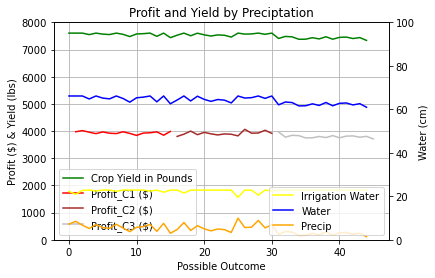

45

45

In [13]:



xs = np.array(range(samples)) # Setting the x axis for number of samples First 30 from Dallas Precip, Next 30 from Lubbock, Last 30 from San Angelo
xs1 = list(range(1,16,1))
xs2 = list(range(16,31,1))
xs3 = list(range(31,46,1))

y0 = np.array([crop_yield[k,i,j].X for k in climate for i in season for j in option])
yc1 = [profit_c1[i,j].X for i in season for j in option]
yc2 = [profit_c2[i,j].X for i in season for j in option]
yc3 = [profit_c3[i,j].X for i in season for j in option]
y2 = [irrigation_water[k,i,j].X for k in climate for i in season for j in option]
y3 = [water[k,i,j].X for k in climate for i in season for j in option]



fig, ax = plt.subplots()

ax.plot(xs,y0*lb_tonne, label = 'Crop Yield in Pounds', color = 'green') # profit is red line
ax.plot(xs1,yc1, label = 'Profit_C1 ($)', color = 'red') # profit is red line
ax.plot(xs2,yc2, label = 'Profit_C2 ($)', color = 'brown') # profit is red line
ax.plot(xs3,yc3, label = 'Profit_C3 ($)', color = 'silver') # profit is red line
ax.set_title('Profit and Yield by Preciptation')
ax.set_xlabel('Possible Outcome')
ax.set_ylabel('Profit ($) & Yield (lbs)')
ax.set_ylim([0,8000])
ax.grid(True)
ax.legend(loc = 'lower left')

ax2 = ax.twinx()
ax2.plot(xs,y2, label = 'Irrigation Water', color = 'yellow') # irrigation is blue line
ax2.plot(xs,y3, label = 'Water', color = 'blue') # water is green line
#ax2.plot(xs,y4, label = 'Alt Water', color = 'purple') # water is green line
ax2.plot(xs,list(rain.values()), label = 'Precip', color = 'orange') # water is green line
ax2.set_ylabel('Water (cm)')
ax2.set_ylim([0,100])
ax2.legend(loc='lower right')


plt.show()

len(xs)
len(rain)


In [14]:
rain['C1','S1','O1']

7.186612500000001

The just CVaR method didn't work out to hot so I did a mix of 50% CVAR 75% and 50% mix of just a weighted average.

In [15]:
# Maximize 50 % CVaR_0.75 profit and 20% expected return
beta  = 0.50
alpha = 0.75


m = Model()

# Set to maximize
m.ModelSense = -1

# Add variables
crop_yield = m.addVars(samples,name = 'yield') # tonne/ha
alt_water = m.addVar(name = 'alt_water') # cm of depth
irrigation_water = m.addVar(ub = max_irrigation_water, name = 'irrigation_water') # cm of depth
profit = m.addVars(samples,obj = (1-beta)/len(precip), name = 'profit') # $
water = m.addVars(samples,name = 'water') # water used for crop, cm of depth

#CVaR Variables
alpha = 0.75
nu = m.addVar(obj=-beta, lb = minrev, ub = maxrev, name='worst')
excess   = m.addVars(samples,obj=-beta/((1-alpha)*samples), ub = maxrev-minrev, name='chance')

# Objective

m.addConstrs( (profit[i] == crop_yield[i] * ha * price +
              -alt_water * cost_alt_water +
              -irrigation_water * cost_irrigation_water
             for i in range(samples) )
            ,name = 'profit')
# Set Constraints



m.addConstrs( (precip[i] + alt_water + irrigation_water >= water[i]  
              for i in range(samples) )
            ,name = 'water' )

for i in range(samples):
    m.addQConstr( (crop_yield[i] <= -3.350 + 0.2064*water[i] - 0.0014*water[i]*water[i] + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water +
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc +
               -0.071 * water[i] * salt_conc_water + 0.033 * water[i] * salt_conc +
               -2.754 * salt_conc_water * salt_conc
               )
               , name = 'crop_yield' )
    
#CVaR Constraints

m.addConstrs((-profit[i]-nu <= excess[i] for i in range(samples)),name='excess')


m.update();

In [16]:
m.optimize()

Gurobi Optimizer version 9.1.1 build v9.1.1rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 135 rows, 183 columns and 450 nonzeros
Model fingerprint: 0x583206f0
Model has 45 quadratic constraints
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  QMatrix range    [1e-03, 1e-03]
  QLMatrix range   [2e-01, 1e+00]
  Objective range  [5e-03, 5e-01]
  Bounds range     [2e+01, 7e+03]
  RHS range        [6e+00, 4e+01]
  QRHS range       [4e+00, 4e+00]
Presolve removed 45 rows and 46 columns
Presolve time: 0.01s
Presolved: 225 rows, 227 columns, 585 nonzeros
Presolved model has 45 second-order cone constraints
Ordering time: 0.00s

Barrier statistics:
 Dense cols : 2
 AA' NZ     : 4.950e+02
 Factor NZ  : 1.128e+03
 Factor Ops : 6.080e+03 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Time
   0   9.217

In [17]:
losses= [-profit[i].X for i in range(samples)]
sol2 = losses.copy()

Model Value 1121.3301366430367 order Qty 19.114956574836736 investment 1146.897394490204 #samples 45
Losses stats:
CVaR(95%,90%,80%,70%) -3778.1229730878017 -3805.5608916433935 -3948.9043523924583 -4092.780059990191
min -5104.199160818816 max -3442.7527565028645 average -4634.831231457885 VaR_75% -4346.773207274503


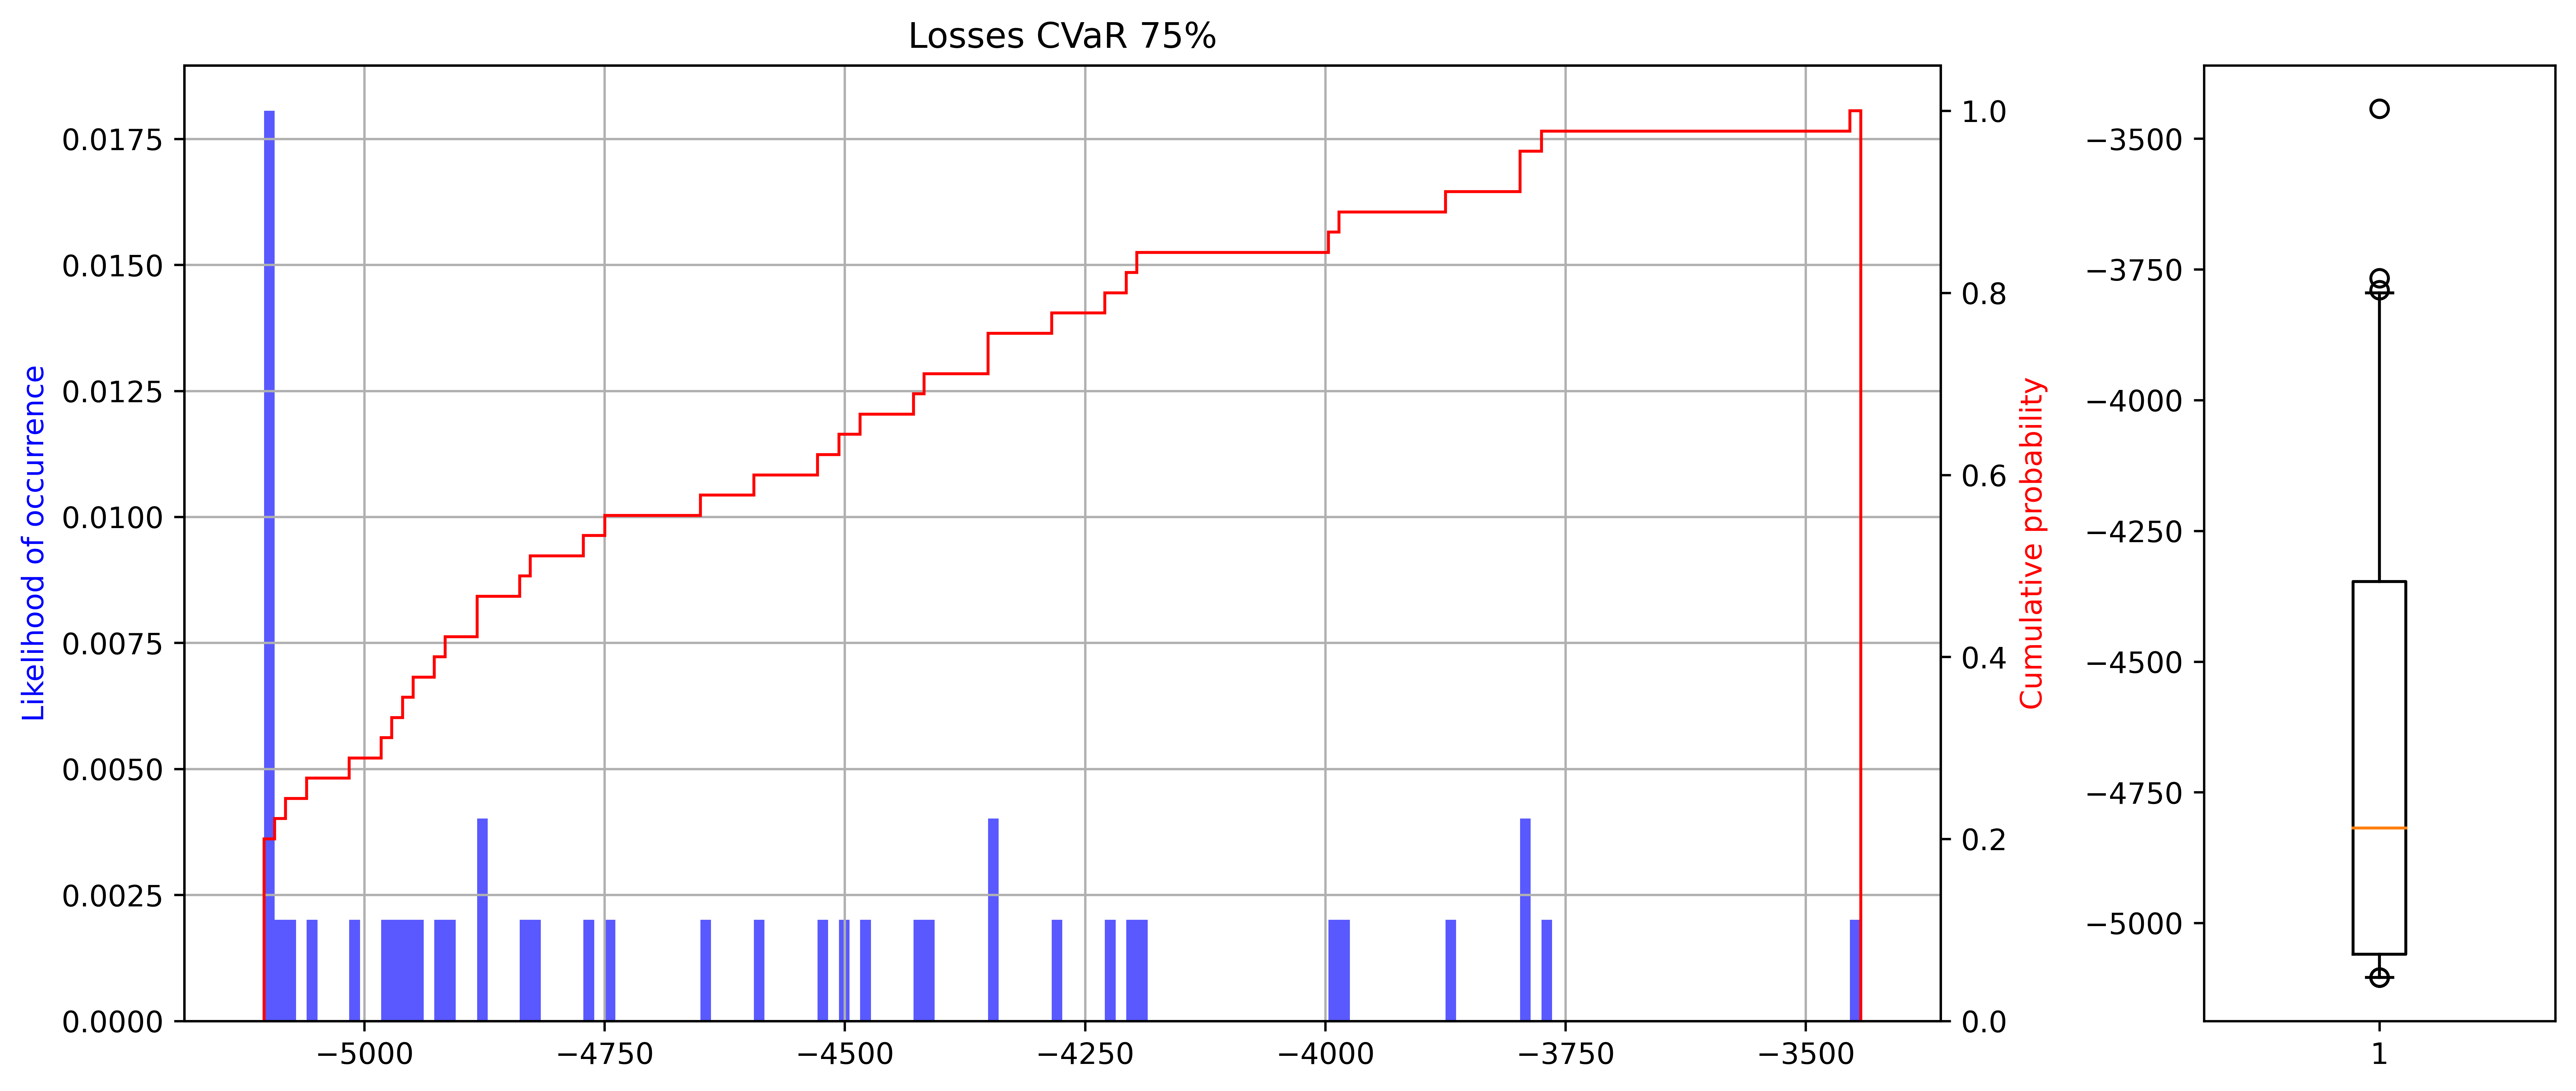

In [18]:
solutionStats(m, alt_water, sol2)
doubleHist(sol2, xlabel='Losses CVaR 75%')